## AY25-26 Term 2 CS421 Group Project

In [1]:
import numpy as np
import pandas as pd
data=np.load("data/training_batch_with_labels.npz")
print(data)

NpzFile 'data/training_batch_with_labels.npz' with keys: X, y


In [27]:
X=data["X"]
y=data["y"]

print("# of interactions:", X.shape[0])
print("# of anomalous and normal users:", np.count_nonzero(y==1), np.count_nonzero(y==0))


df=pd.DataFrame(X)
labels=pd.DataFrame(y)
df.rename(columns={0:"user",1:"item",2:"rating"},inplace=True)
print("# of items:", df['item'].unique().shape[0])

# of interactions: 177346
# of anomalous and normal users: 100 1000
# of items: 993


In [28]:
df.head(100)

,user,item,rating
0,304,0,3
1,304,1,3
2,304,14,3
3,304,17,4
4,304,19,4
...,...,...,...
95,304,824,3
96,304,826,3
97,304,828,4
98,304,847,3


In [29]:
labels.rename(columns={0:"user",1:"label"},inplace=True)

In [30]:
labels.head(10)

,user,label
0,100,0
1,101,0
2,102,0
3,103,0
4,104,0
5,105,0
6,106,0
7,107,0
8,108,0
9,109,0


In [31]:
labels.to_csv('ground_truth.csv', index=False, header=False)

In [33]:
## Example with random scores
data_pred=np.load("data/subset_training_batch.npz")
X_pred=data_pred["X"]
n_users = len(np.unique(X_pred[:, 0]))
print(f'No of users : {n_users}')

No of users : 220


## Feature Engineering

The objective is to derive user-level behavioural features from the interaction dataset (user, item, rating) so that the model can learn behavioural patterns that distinguish anomalous users from normal users.

Since anomaly detection occurs at the user level, all features must summarize a user's rating behaviour across items.

In [45]:
# Check for null values
df.isnull().sum()
# Identify if a user has repeatedly rated the same item
repeat_counts = df.groupby(["user", "item"]).size()
repeated = repeat_counts[repeat_counts > 1]
repeated

df = df.groupby(["user", "item"])["rating"].mean().reset_index()

user_stats = df.groupby("user")["rating"].agg([
    "mean",
    "std",
    "min",
    "max",
    "count"
]).rename(columns={
    "mean": "user_mean_rating",
    "std": "user_rating_std",
    "min": "user_min_rating",
    "max": "user_max_rating",
    "count": "num_ratings"
})

print(f'# of users with mean ratinng > 4 : {user_stats[user_stats['user_mean_rating'] > 4].shape[0]}')
print(f"Total users: {user_stats.shape[0]}")

# Compute the rating distribution
rating_dist = pd.crosstab(df["user"], df["rating"])
rating_dist.columns = [f"rating_{c}_count" for c in rating_dist.columns]

p = rating_dist.div(rating_dist.sum(axis=1), axis=0)
rating_entropy = -(p * np.log(p + 1e-9)).sum(axis=1)
rating_entropy = rating_entropy.rename("rating_entropy").reset_index()

# Extreme rating ratio (ratings 0,1,5 treated as extreme)
extreme_ratio = (
    (rating_dist.get(0.0,0) + rating_dist.get(1.0,0) + rating_dist.get(5.0,0)) 
    / rating_dist.sum(axis=1)
)
extreme_ratio = extreme_ratio.rename("extreme_rating_ratio").reset_index()

# Rating skewness
rating_skew = df.groupby("user")["rating"].skew().rename("rating_skew").reset_index()

# Rating kurtosis
rating_kurt = df.groupby("user")["rating"].apply(pd.Series.kurt).rename("rating_kurtosis").reset_index()

# Mean absolute deviation from user mean
mad = df.groupby("user").apply(
    lambda x: np.mean(np.abs(x["rating"] - x["rating"].mean()))
)
mad = mad.rename("rating_mad").reset_index()


# Compute the item coverage per user
items_per_user = df.groupby("user")["item"].nunique()
item_coverage = items_per_user / 1000
item_coverage = item_coverage.rename("item_coverage")
item_coverage_df = item_coverage.reset_index()


# Combine all engineered features
user_features = user_stats.reset_index()
user_features = user_features.merge(
    item_coverage_df, on="user", how="left"
)
user_features = user_features.merge(
    user_avg_popularity, on="user", how="left"
)
user_features = user_features.merge(
    rating_dist.reset_index(), on="user", how="left"
)

user_features = user_features.merge(
    labels, on="user", how="left"
)

user_features = user_features.merge(rating_entropy, on="user", how="left")
user_features = user_features.merge(extreme_ratio, on="user", how="left")
user_features = user_features.merge(rating_skew, on="user", how="left")
user_features = user_features.merge(rating_kurt, on="user", how="left")
user_features = user_features.merge(mad, on="user", how="left")

user_features.columns

rating_cols = ['rating_0.0_count', 'rating_1.0_count', 'rating_2.0_count', 
               'rating_3.0_count', 'rating_4.0_count', 'rating_5.0_count']

for col in rating_cols:
    # Create percentage version
    pct_col = col.replace('_count', '_%')
    user_features[col] = user_features[col] / user_features['num_ratings'] 
    user_features = user_features.rename(columns={col: pct_col})

user_features = user_features.drop(columns=['avg_item_popularity'])
user_features = user_features.fillna(0)
user_features
user_features.to_csv('user_features.csv')


# of users with mean ratinng > 4 : 139
Total users: 1100


/var/folders/df/nqyr7tsx4xq5y1nsh200wt0w0000gn/T/ipykernel_15371/3375085121.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mad = df.groupby("user").apply(


Now that we have our user behavioural features, we can start builing a baseline model.


In [42]:
# user_features.dtypes
# #  Separate Features and labels
X = user_features.drop(columns=["user", "label"])
y = user_features["label"]
X.isnull().sum()

from sklearn.model_selection import train_test_split
# Since dataset is imbalanced we startify based on y
# to ensure both train and test set have the same anomaly ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
# Perform standardization of features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
# transform only no fitting occurs so that data leakage does not happen
X_test_scaled = scaler.transform(X_test)


from sklearn.linear_model import LogisticRegression

# Balanced weighting increases penalty for misclassifying anomalies.
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

In [43]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Normal", "Actual Anomaly"],
    columns=["Predicted Normal", "Predicted Anomaly"]
)
print("Confusion Matrix:")
print(cm_df)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
print("\nROC-AUC:", roc_auc)

# AUPRC (Average Precision Score)
auprc = average_precision_score(y_test, y_prob)
print("AUPRC:", auprc)

Confusion Matrix:
                Predicted Normal  Predicted Anomaly
Actual Normal                158                 42
Actual Anomaly                 9                 11

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.79      0.86       200
           1       0.21      0.55      0.30        20

    accuracy                           0.77       220
   macro avg       0.58      0.67      0.58       220
weighted avg       0.88      0.77      0.81       220


ROC-AUC: 0.7955
AUPRC: 0.5288469466371253


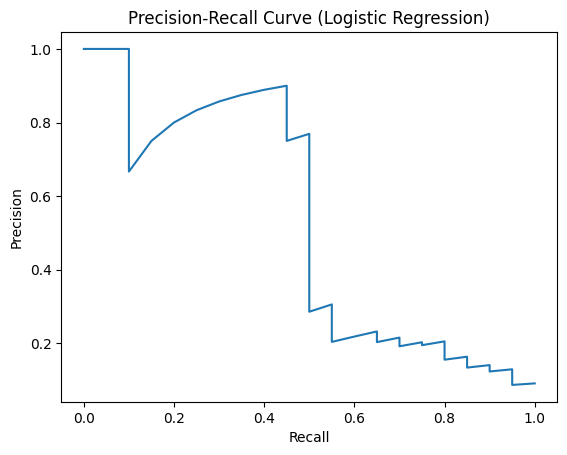

In [44]:
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Logistic Regression)")
plt.show()